# Portfolio Risk Characteristics

Focuses on how the portfolio behaves as a risk object: which positions drive volatility,
how risk concentration shifts over time, and how asset classes co-move.

**Sections**
1. Setup
2. Weighted Vol Contribution
3. Correlation Analysis
4. Equity vs Benchmark

## 1. Setup

In [15]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print("Working directory:", repo_root)

Working directory: /home/martin/python/risk-assessment


In [16]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

from data_loader import clean_prices, load_positions, load_prices

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})

positions = load_positions()
raw = load_prices()
clean = clean_prices(raw)

prices_wide = clean.pivot(index="date", columns="instrument_id", values="price").sort_index()
returns = prices_wide.pct_change().dropna(how="all")

weights = positions.set_index("instrument_id")["weight"]
common = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])
ann_vol = returns[common].std() * np.sqrt(252)

print(f"Returns: {returns.shape}  |  portfolio series: {len(port_returns)} days")

Returns: (252, 18)  |  portfolio series: 252 days


In [17]:
# Sub-class ordering and weight-normalised sub-class return series (used throughout)
SUB_CLASS_ORDER = ["SWISS_EQUITY", "EUR_EQUITY", "CHF_CORP", "CHF_GOVT", "EUR_GOVT"]
inst_meta_sc = positions.set_index("instrument_id")["sub_class"]

inst_order, sc_sizes = [], []
for sc in SUB_CLASS_ORDER:
    members = sorted(inst_meta_sc[inst_meta_sc == sc].index.intersection(returns.columns))
    inst_order.extend(members)
    sc_sizes.append(len(members))
sc_boundaries = np.cumsum(sc_sizes)[:-1] - 0.5

inst_wt = positions.set_index("instrument_id")[["sub_class", "weight"]]
sub_ret = {}
for sc in SUB_CLASS_ORDER:
    ids = inst_wt[inst_wt["sub_class"] == sc].index.intersection(returns.columns)
    w = inst_wt.loc[ids, "weight"]
    sub_ret[sc] = returns[ids].dot(w / w.sum())
sub_ret = pd.DataFrame(sub_ret)[SUB_CLASS_ORDER]

In [18]:
from pathlib import Path

_bm_path = Path("data/benchmark_prices.parquet")
if not _bm_path.exists():
    raise FileNotFoundError(
        "data/benchmark_prices.parquet not found — run fetch_benchmarks.ipynb first."
    )

bm_raw = pd.read_parquet(_bm_path)
bm_wide = bm_raw.pivot(index="date", columns="instrument_id", values="price").sort_index()
bm_returns = bm_wide.pct_change().dropna(how="all")

# Map each equity sub-class to its benchmark
EQUITY_GROUPS = {
    "SWISS_EQUITY": {"instruments": [i for i in inst_order if inst_meta_sc[i] == "SWISS_EQUITY"],
                     "benchmark": "SPI"},
    "EUR_EQUITY":   {"instruments": [i for i in inst_order if inst_meta_sc[i] == "EUR_EQUITY"],
                     "benchmark": "STOXX50E"},
}

print("Benchmark returns loaded:", list(bm_returns.columns))
print(f"Date range: {bm_returns.index.min().date()} → {bm_returns.index.max().date()}")

Benchmark returns loaded: ['SPI', 'STOXX50E']
Date range: 2025-04-01 → 2026-03-18


## 2. Weighted Vol Contribution

A position's contribution to portfolio volatility is approximately
$w_i \cdot \sigma_i \cdot \rho_{i,P}$ — weight × annualised vol × correlation with the portfolio.
This is more informative than standalone vol: a high-vol position at 1% weight contributes
far less than a moderate-vol position at 20% weight that moves with the portfolio.

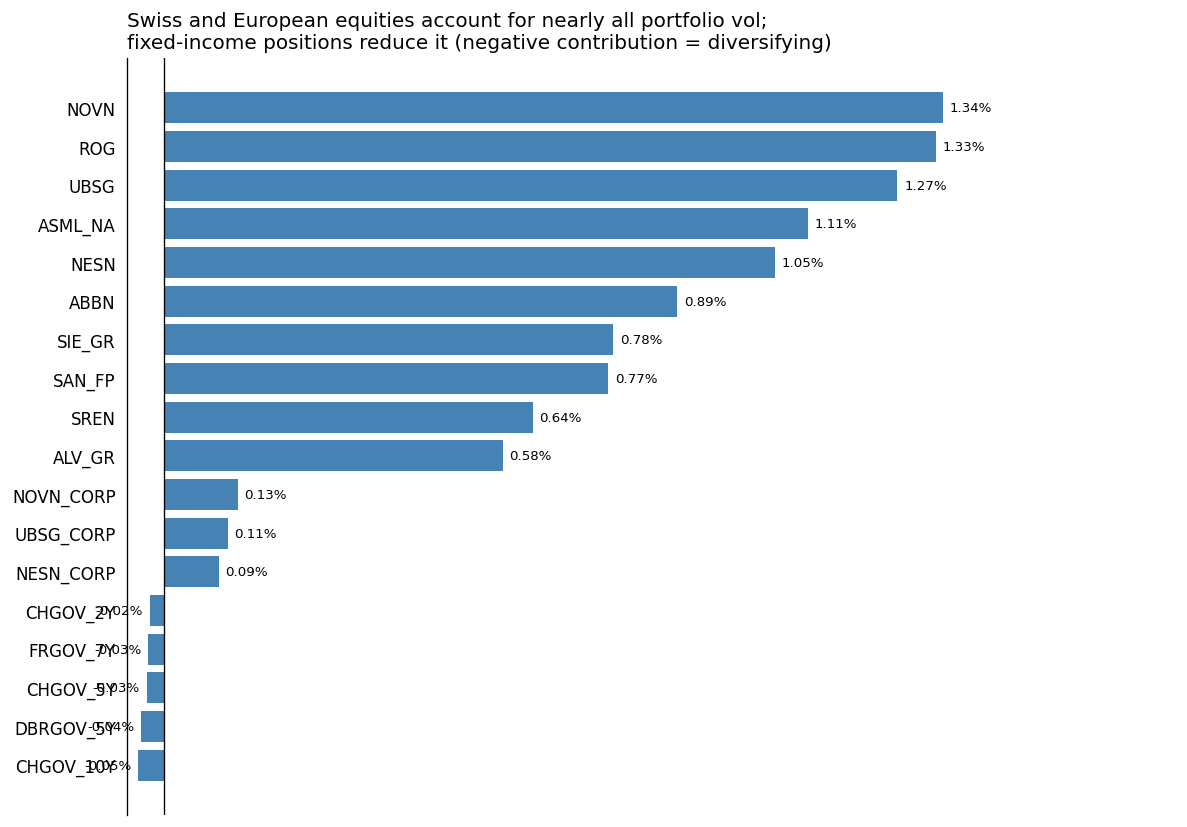

In [19]:
corr_with_port = returns[common].corrwith(port_returns)
vol_contrib = weights[common] * ann_vol * corr_with_port
vol_contrib_sorted = vol_contrib.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(vol_contrib_sorted.index, vol_contrib_sorted.values, color="steelblue")
ax.bar_label(bars, labels=[f"{v:.2%}" for v in vol_contrib_sorted.values], padding=4, fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(vol_contrib_sorted.min() * 1.4, vol_contrib_sorted.max() * 1.3)
ax.set_title(
    "Swiss and European equities account for nearly all portfolio vol;\n"
    "fixed-income positions reduce it (negative contribution = diversifying)",
    loc="left",
)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax.tick_params(axis="y", left=False)
plt.tight_layout()
plt.show()

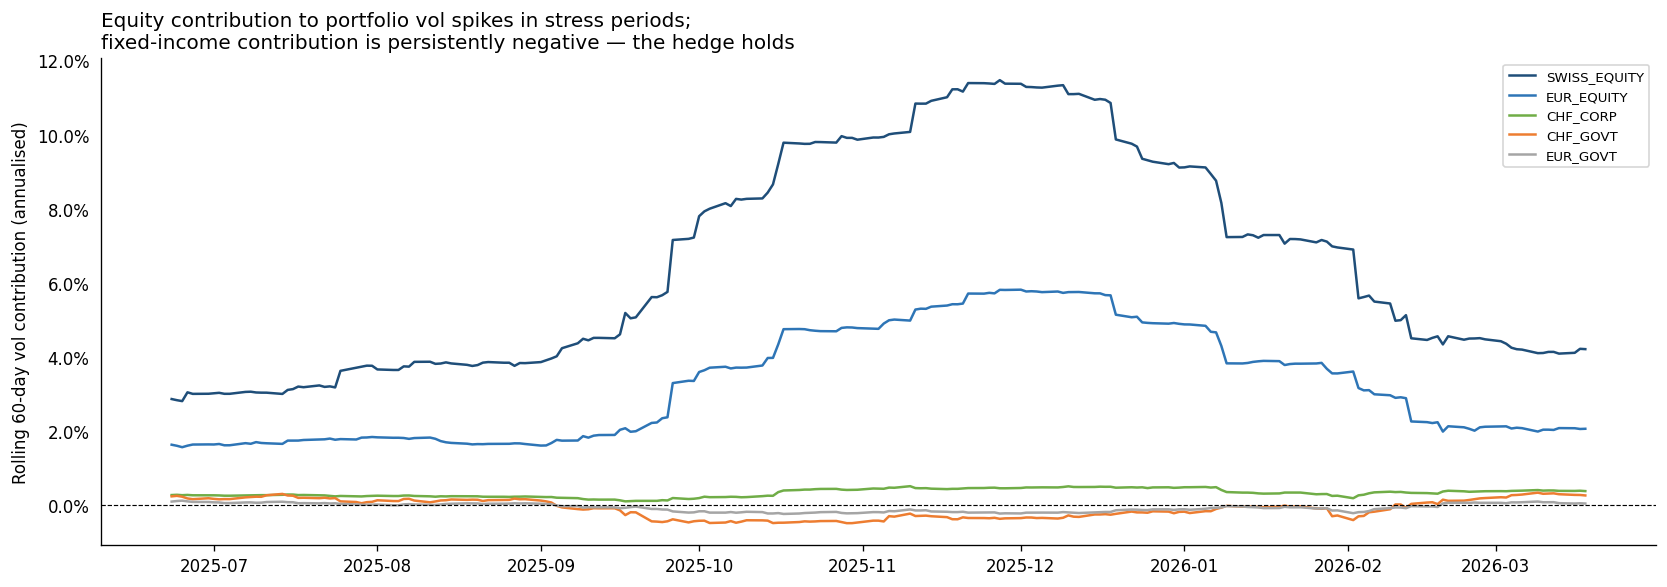

In [20]:
WINDOW = 60

roll_contrib = pd.DataFrame({
    iid: weights[iid]
         * returns[iid].rolling(WINDOW).std() * np.sqrt(252)
         * returns[iid].rolling(WINDOW).corr(port_returns)
    for iid in common
}).dropna()

SC_COLORS = {
    "SWISS_EQUITY": "#1f4e79",
    "EUR_EQUITY":   "#2e75b6",
    "CHF_CORP":     "#70ad47",
    "CHF_GOVT":     "#ed7d31",
    "EUR_GOVT":     "#a5a5a5",
}

roll_contrib_sc = pd.DataFrame({
    sc: roll_contrib[
        [iid for iid in inst_order if iid in roll_contrib.columns and inst_meta_sc[iid] == sc]
    ].sum(axis=1)
    for sc in SUB_CLASS_ORDER
})

fig, ax = plt.subplots(figsize=(14, 5))
for sc in SUB_CLASS_ORDER:
    ax.plot(roll_contrib_sc.index, roll_contrib_sc[sc],
            label=sc, color=SC_COLORS[sc], linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_ylabel(f"Rolling {WINDOW}-day vol contribution (annualised)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_title(
    "Equity contribution to portfolio vol spikes in stress periods;\n"
    "fixed-income contribution is persistently negative — the hedge holds",
    loc="left",
)
ax.legend(loc="upper right", fontsize=8)
ax.tick_params(axis="y", left=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

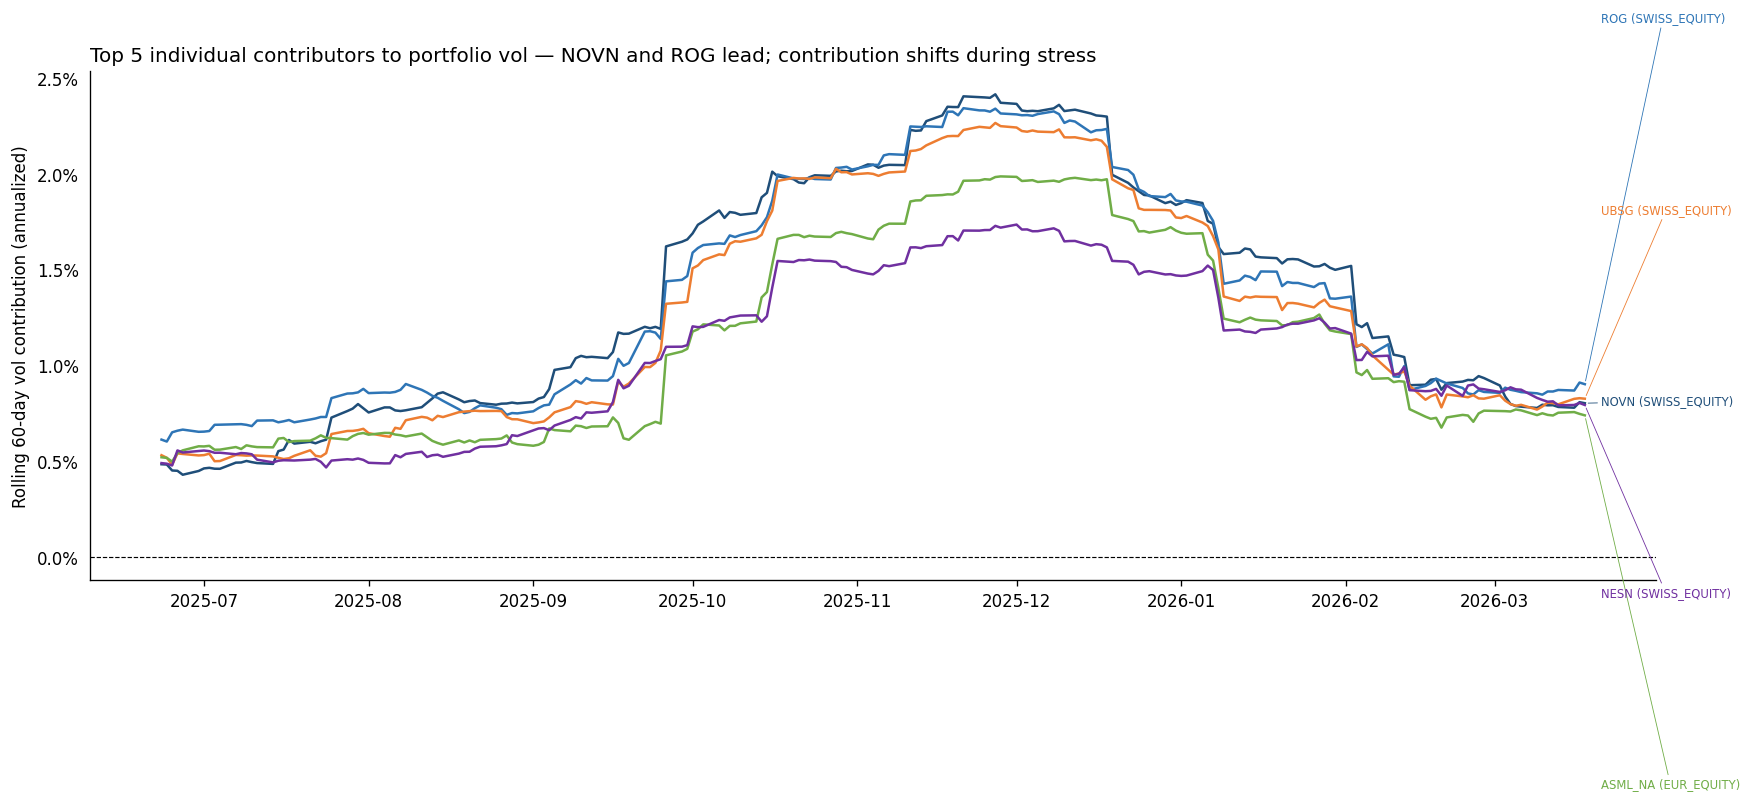

In [21]:
N_TOP = 5
avg_contrib = roll_contrib.mean().sort_values(ascending=False)
top_instruments = avg_contrib.head(N_TOP).index.tolist()

TOP_COLORS = ["#1f4e79", "#2e75b6", "#ed7d31", "#70ad47", "#7030a0"]
inst_color = dict(zip(top_instruments, TOP_COLORS, strict=True))

last_date = roll_contrib.index[-1]
fig, ax = plt.subplots(figsize=(14, 5))

for iid in top_instruments:
    ax.plot(roll_contrib.index, roll_contrib[iid],
            color=inst_color[iid], linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_ylabel(f"Rolling {WINDOW}-day vol contribution (annualized)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_title(
    f"Top {N_TOP} individual contributors to portfolio vol — "
    f"{top_instruments[0]} and {top_instruments[1]} lead; "
    "contribution shifts during stress",
    loc="left",
)
ax.tick_params(axis="y", left=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()


def spread_labels(vals, min_gap):
    """Iteratively push label positions apart until no two are closer than min_gap."""
    items = sorted(enumerate(vals), key=lambda x: x[1])
    pos = [v for _, v in items]
    for _ in range(300):
        changed = False
        for i in range(1, len(pos)):
            if pos[i] - pos[i - 1] < min_gap:
                mid = (pos[i] + pos[i - 1]) / 2
                pos[i - 1] = mid - min_gap / 2
                pos[i] = mid + min_gap / 2
                changed = True
        if not changed:
            break
    result = [None] * len(vals)
    for i, (orig_idx, _) in enumerate(items):
        result[orig_idx] = pos[i]
    return result


end_vals = [float(roll_contrib[iid].iloc[-1]) for iid in top_instruments]
label_x = last_date + pd.Timedelta(days=3)
adjusted_y = spread_labels(end_vals, min_gap=0.010)

for idx, iid in enumerate(top_instruments):
    color = inst_color[iid]
    ax.annotate(
        f"{iid} ({inst_meta_sc[iid]})",
        xy=(last_date, end_vals[idx]),
        xytext=(label_x, adjusted_y[idx]),
        xycoords="data",
        textcoords="data",
        fontsize=7,
        color=color,
        va="center",
        clip_on=False,
        arrowprops=dict(arrowstyle="-", color=color, lw=0.5, shrinkA=0, shrinkB=2),
    )

plt.show()

## 3. Correlation Analysis

### 3.1 Asset Classes — Full-Sample Heatmap

Sub-class returns are the weight-normalised portfolio return within each sub-class.
The 5×5 matrix summarises cross-class diversification at a glance.

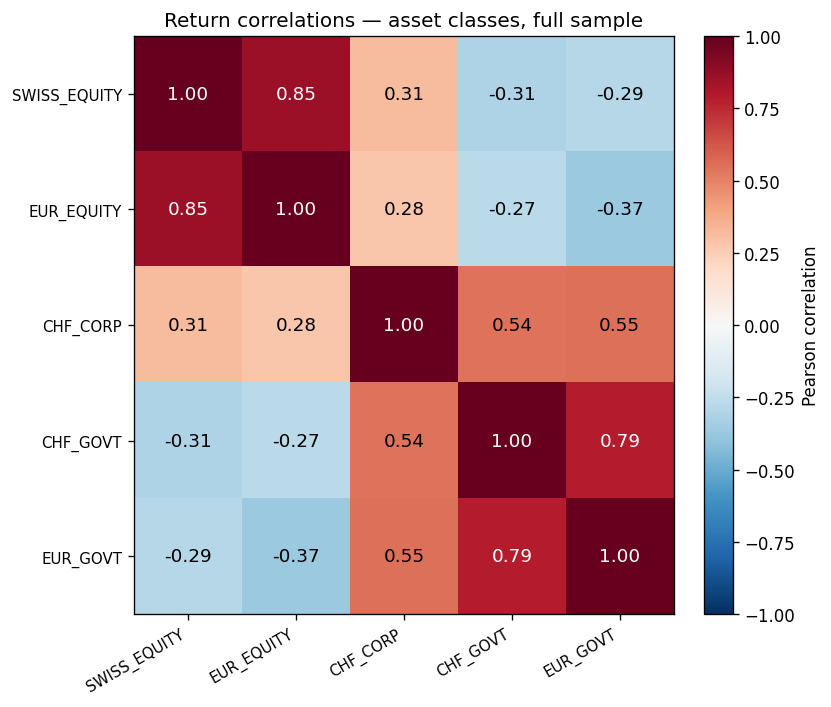

In [22]:
corr_sc = sub_ret.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_sc.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.05, label="Pearson correlation")

n = len(SUB_CLASS_ORDER)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(SUB_CLASS_ORDER, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(SUB_CLASS_ORDER, fontsize=9)

for i, row_vals in enumerate(corr_sc.values):
    for j, val in enumerate(row_vals):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=11,
                color="white" if abs(val) > 0.65 else "black")

ax.set_title("Return correlations — asset classes, full sample")
plt.tight_layout()
plt.show()

### 3.2 Rolling 60-Day Correlations

Asset-class level: all 10 pairwise rolling correlations, coloured by pair type
(equity-equity, equity-govt, etc.).
Individual level: rolling correlation of each instrument with the portfolio return,
displayed as a heatmap over time.

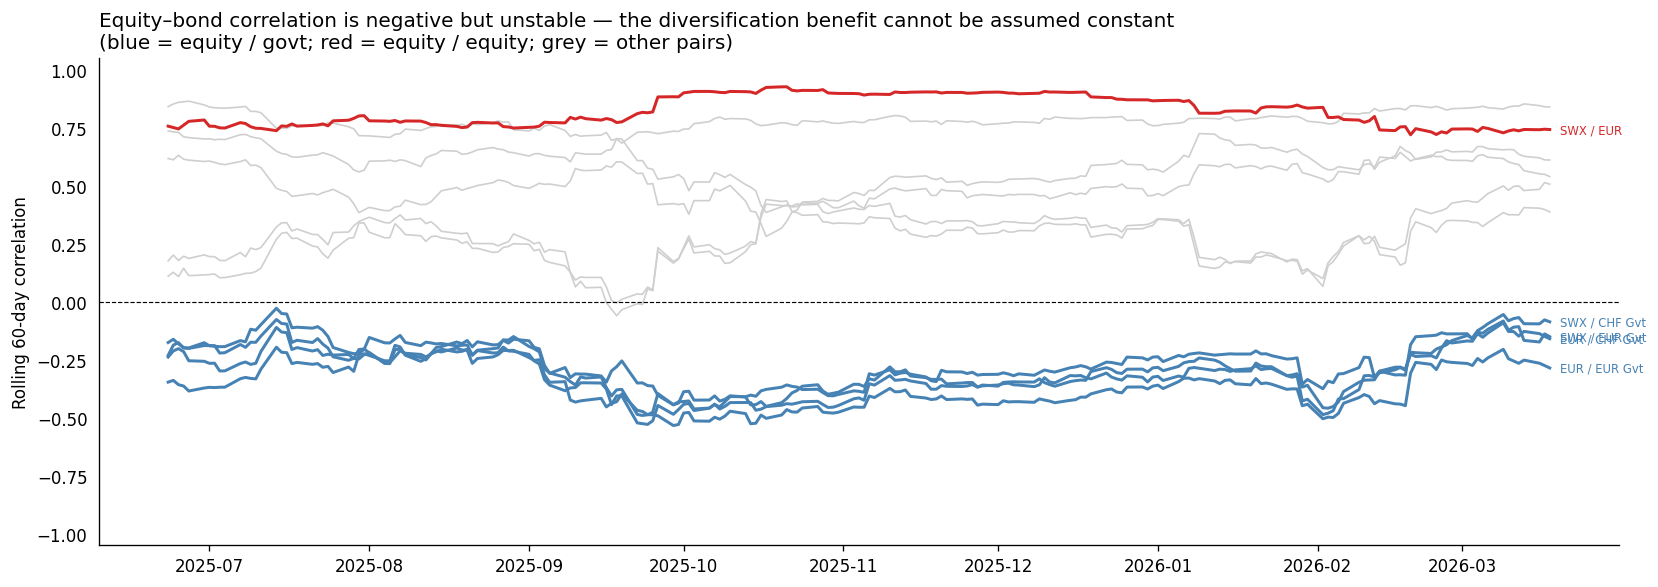

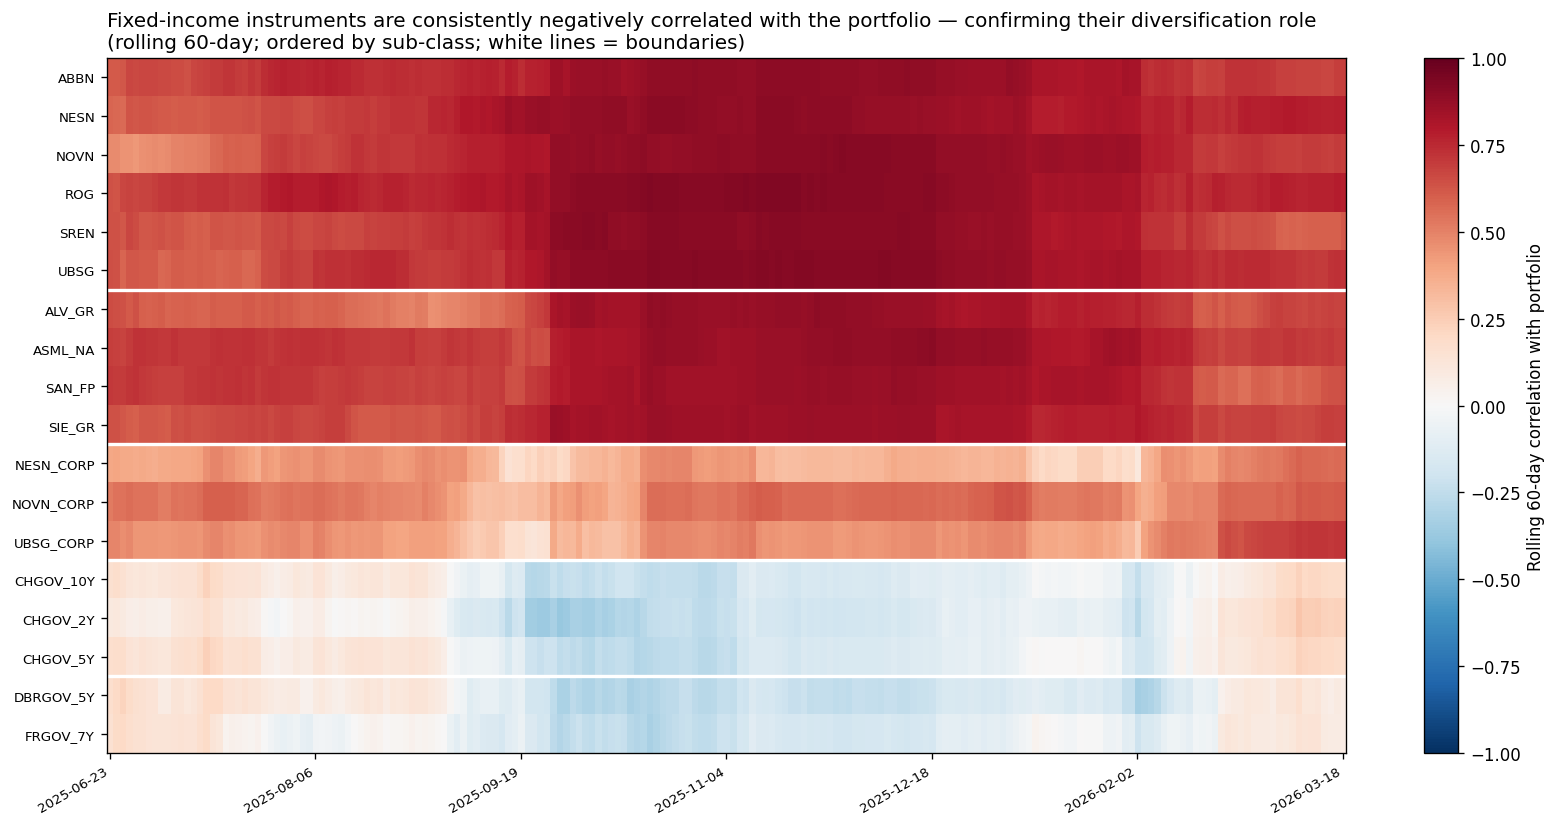

In [23]:
SHORT = {
    "SWISS_EQUITY": "SWX",
    "EUR_EQUITY":   "EUR",
    "CHF_CORP":     "Corp",
    "CHF_GOVT":     "CHF Gvt",
    "EUR_GOVT":     "EUR Gvt",
}

pairs = list(combinations(SUB_CLASS_ORDER, 2))


def pair_type(a, b):
    eq = {"SWISS_EQUITY", "EUR_EQUITY"}
    cr = {"CHF_CORP"}
    return "-".join(
        sorted("equity" if x in eq else "credit" if x in cr else "govt" for x in (a, b))
    )


rolling_sc_df = pd.DataFrame({
    f"{a} / {b}": sub_ret[a].rolling(WINDOW).corr(sub_ret[b])
    for a, b in pairs
}).dropna()

fig, ax = plt.subplots(figsize=(14, 5))

for a, b in pairs:
    if pair_type(a, b) not in ("equity-govt", "equity-equity"):
        ax.plot(rolling_sc_df.index, rolling_sc_df[f"{a} / {b}"],
                color="#CFCFCF", linewidth=1.0, zorder=1)

last_date = rolling_sc_df.index[-1]
for a, b in pairs:
    pt = pair_type(a, b)
    if pt == "equity-govt":
        color = "steelblue"
    elif pt == "equity-equity":
        color = "tab:red"
    else:
        continue
    col = f"{a} / {b}"
    ax.plot(rolling_sc_df.index, rolling_sc_df[col], color=color, linewidth=1.8, zorder=3)
    ax.annotate(
        f"{SHORT[a]} / {SHORT[b]}",
        xy=(last_date, rolling_sc_df[col].iloc[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        fontsize=7,
        color=color,
        va="center",
        clip_on=False,
    )

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_ylim(-1.05, 1.05)
ax.set_ylabel(f"Rolling {WINDOW}-day correlation")
ax.set_title(
    "Equity\u2013bond correlation is negative but unstable \u2014 "
    "the diversification benefit cannot be assumed constant\n"
    "(blue = equity / govt; red = equity / equity; grey = other pairs)",
    loc="left",
)
ax.tick_params(axis="y", left=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Individual instruments: rolling correlation with portfolio return ──
roll_corr_port = pd.DataFrame({
    iid: returns[iid].rolling(WINDOW).corr(port_returns)
    for iid in inst_order
}).dropna()

data = roll_corr_port[inst_order].T.values
n_dates = len(roll_corr_port)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(data, aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax, label=f"Rolling {WINDOW}-day correlation with portfolio")

step = max(1, n_dates // 6)
ax.set_xticks(range(0, n_dates, step))
ax.set_xticklabels(
    [str(roll_corr_port.index[i].date()) for i in range(0, n_dates, step)],
    rotation=30,
    ha="right",
    fontsize=8,
)
ax.set_yticks(range(len(inst_order)))
ax.set_yticklabels(inst_order, fontsize=8)
for b in sc_boundaries:
    ax.axhline(b, color="white", linewidth=2)

ax.set_title(
    "Fixed-income instruments are consistently negatively correlated with the portfolio \u2014 "
    "confirming their diversification role\n"
    f"(rolling {WINDOW}-day; ordered by sub-class; white lines = boundaries)",
    loc="left",
)
plt.tight_layout()
plt.show()